#### Finding the optimal Learning Rate - Through learning rate sweep
so  in this experiment we would be finding the optimal learning rate using the learning rate sweep alogrithm

#### All imports here

In [1]:
import os 
os.environ['KMP_DUPLICATE_LIB_OK'] = "TRUE" #this was a workaround to make torch import and run on my computer
import torch
import matplotlib.pyplot as plt 
import torch.nn.functional as F

#### Dividing the data into usable datapoints 

In [2]:
file = open("input.txt" , 'r')
content = file.read()
sentences = content.splitlines()

all_words = []

for sentence in sentences:
    words = sentence.split()
    all_words.extend(words)

unique_words = sorted(list(set(all_words)))

#### Creating the string to integer mapping so as to break the words into indices and those indices further on to vectors

In [3]:
#creating the mapping 
stoi = {s:i+1 for i , s in enumerate(unique_words)}
stoi["."] = 0#this is the special starting token marking the start and the end 
itos ={i:s for s, i in stoi.items()}
vocab_size = len(itos)
vocab_size

25671

##### Dividing the model into train val  and test datasets :

so this division is being done on the philosophy

train = 80%
val = 10%
test = 10%

In [4]:
##the model hyperparameters
window_size = 10
seed = 3801

In [5]:
def build_dataset(sentences):
    X , Y=  [] , []
    context_window = window_size

    for sentence in sentences:
        words =sentence.split()
        context=  [0]*context_window

        for word in words+["."]:
            ix = stoi[word]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
            #yes - it has rolling context ie 1 ,2 , 3 - > 4; 2 ,3 , 4-> 5----> this NPLM model is also  an  n gram in its core but just with embeddings
            # and way larger and alterable context


    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print(X.shape , Y.shape)
    return X , Y 


In [6]:
#the division philosophy - mentioned above
train_percent = 0.8
val_percent = 0.1 
test_percent = 0.1#this is the remaining - one we can say as showed below


In [7]:
import random 
random.seed(seed)
random.shuffle(sentences)

n1 = int(train_percent*(len(sentences)))
n2= int((train_percent+val_percent)*(len(sentences)))

Xtr , Ytr = build_dataset(sentences[:n1])
Xval , Yval = build_dataset(sentences[n1:n2])
Xtest , Ytest = build_dataset(sentences[n2:])

torch.Size([194521, 10]) torch.Size([194521])
torch.Size([24075, 10]) torch.Size([24075])
torch.Size([24055, 10]) torch.Size([24055])


In [8]:
#helper variables for the parameters  
embeddings = 100
hidden_neuron  = 200
g = torch.Generator().manual_seed(seed)


In [9]:
#parameters 
C = torch.randn((vocab_size , embeddings) ,generator  =g)
W1 = torch.randn((embeddings*window_size , hidden_neuron) , generator = g)*0.01
b1 = torch.randn((hidden_neuron) ,  generator = g)
W2 = torch.randn((hidden_neuron , vocab_size) , generator = g)*0.001
b2 = torch.randn((vocab_size) , generator = g)*1

parameters = [C , W1 , W2 , b1 , b2]
sum(p.nelement() for p in parameters)
wd  = 1e-4

for p in parameters:
    p.requires_grad = True

In [10]:
#performing the learning rate sweep 
lre =torch.linspace(-3 ,0 , 1000)
lrs = 10**lre

In [11]:
batch_size = 200

In [12]:
lossi = []
lri = []

for i in range(1000):

    #minibatch construction - mentioned in the paper
    ix = torch.randint(0 , Xtr.shape[0] , (batch_size , ) , generator = g )
    Xb ,Yb = Xtr[ix] , Ytr[ix]
    
    ##forward pass 
    emb = C[Xb]
    embcat = emb.view(batch_size , window_size*embeddings)
    h = torch.tanh(embcat@W1 + b1)
    logits = h@W2+b2 
    loss = F.cross_entropy(logits , Yb)
    perplexity = loss.exp()


    #implementing the backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()


    lossi.append(loss.item())
    lr = lrs[i]
    lri.append(lre[i])
    for p in parameters:
        p.data += -lr*p.grad - wd*p.data



print(loss.item())

17.869613647460938


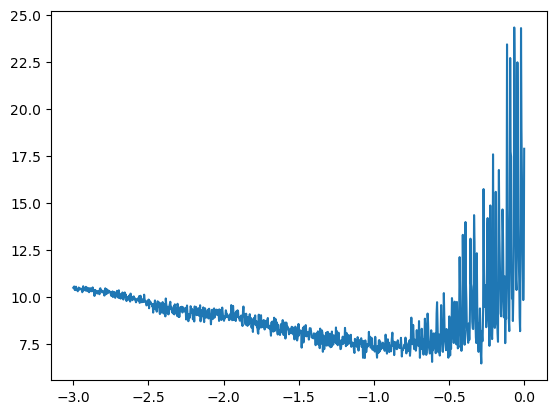

In [13]:
plt.plot(lri , lossi)
plt.show()

##### the learning rate test shows stable optimization up untl lrs =10^-0.9 and os beyond this point the loss becomes extremely unstable and thus the maximum usable lr being potrayed through this graph is approx 0.1 ie 10^-1 